# PEMS08 Traffic Flow — v6
- SEQ_LEN = 36 (3 hours context)
- PRED_LEN = 3 (predict next 15 min)
- Global normalisation (80/10/10 split)
- Dropout = 0.3

In [5]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Option B: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [6]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [7]:
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [8]:
data = np.load(DATA_PATH)
flow = data['data'][:, :, 0].astype(np.float32)
print('Shape:', flow.shape)
print(f'min={flow.min():.1f}  max={flow.max():.1f}  mean={flow.mean():.1f}')

Shape: (17856, 170)
min=0.0  max=1147.0  mean=230.7


In [9]:
train_end = int(0.8 * len(flow))
mean = flow[:train_end].mean()
std  = flow[:train_end].std()
flow = (flow - mean) / std
print(f'Global norm  mean={mean:.2f}  std={std:.2f}')

Global norm  mean=230.56  std=146.18


In [10]:
SEQ_LEN  = 36
PRED_LEN = 3

X, Y = [], []
for i in range(len(flow) - SEQ_LEN - PRED_LEN + 1):
    X.append(flow[i           : i + SEQ_LEN])
    Y.append(flow[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

split     = int(0.8 * len(X))
val_split = int(0.9 * split)

X_train, Y_train = X[:val_split],       Y[:val_split]
X_val,   Y_val   = X[val_split:split],  Y[val_split:split]
X_test,  Y_test  = X[split:],           Y[split:]

print(f'SEQ_LEN={SEQ_LEN}  PRED_LEN={PRED_LEN}')
print(f'Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

SEQ_LEN=36  PRED_LEN=3
Train (12828, 36, 170) | Val (1426, 36, 170) | Test (3564, 36, 170)


In [11]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

BATCH = 128
train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [12]:
class LSTMModel(nn.Module):
    def __init__(self, sensors=170, hidden=256, num_layers=2, dropout=0.3, pred_len=3):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, sensors * pred_len)

    def forward(self, x):
        h, _ = self.lstm(x)
        out   = self.fc(self.drop(h[:, -1, :]))
        return out.view(x.size(0), self.pred_len, -1)

model = LSTMModel(pred_len=PRED_LEN).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 1,095,678


In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
patience         = 15
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    lr  = optimizer.param_groups[0]['lr']
    gap = val_loss - train_loss
    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | Gap {gap:.4f} | LR {lr:.2e}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.1798 | Val 0.1310 | Gap -0.0488 | LR 1.00e-03
Epoch   2 | Train 0.0807 | Val 0.1157 | Gap 0.0350 | LR 1.00e-03
Epoch   3 | Train 0.0672 | Val 0.1111 | Gap 0.0438 | LR 1.00e-03
Epoch   4 | Train 0.0592 | Val 0.1071 | Gap 0.0479 | LR 1.00e-03
Epoch   5 | Train 0.0536 | Val 0.1023 | Gap 0.0487 | LR 1.00e-03
Epoch   6 | Train 0.0501 | Val 0.0973 | Gap 0.0472 | LR 1.00e-03
Epoch   7 | Train 0.0477 | Val 0.0957 | Gap 0.0480 | LR 1.00e-03
Epoch   8 | Train 0.0461 | Val 0.0940 | Gap 0.0478 | LR 1.00e-03
Epoch   9 | Train 0.0443 | Val 0.0915 | Gap 0.0473 | LR 1.00e-03
Epoch  10 | Train 0.0428 | Val 0.0902 | Gap 0.0474 | LR 1.00e-03
Epoch  11 | Train 0.0420 | Val 0.0902 | Gap 0.0482 | LR 1.00e-03
Epoch  12 | Train 0.0414 | Val 0.0882 | Gap 0.0468 | LR 1.00e-03
Epoch  13 | Train 0.0408 | Val 0.0888 | Gap 0.0480 | LR 1.00e-03
Epoch  14 | Train 0.0402 | Val 0.0860 | Gap 0.0458 | LR 1.00e-03
Epoch  15 | Train 0.0397 | Val 0.0873 | Gap 0.0477 | LR 1.00e-03
Epoch  16 | Train 0.0393

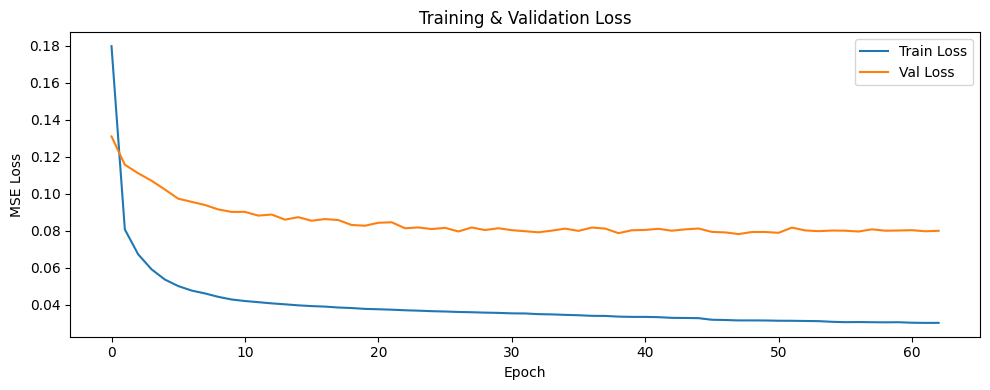

Final gap: 0.0498


In [14]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Final gap: {val_losses[-1] - train_losses[-1]:.4f}')

Overall  MAE=18.3768  RMSE=28.5833  MAPE=12.1579%

  Step 1 (+5 min)  MAE=18.1494
  Step 2 (+10 min)  MAE=18.3528
  Step 3 (+15 min)  MAE=18.6281


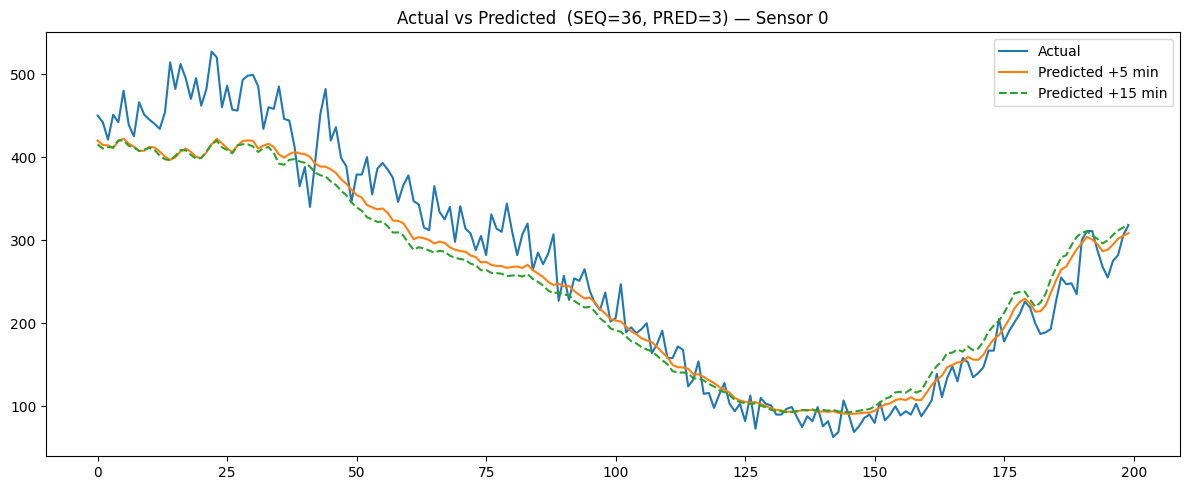

In [15]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)
actual = np.concatenate(actual)

preds  = preds  * std + mean
actual = actual * std + mean

mae  = mean_absolute_error(actual.reshape(-1), preds.reshape(-1))
rmse = np.sqrt(mean_squared_error(actual.reshape(-1), preds.reshape(-1)))
mask = actual.reshape(-1) > 1.0
mape = np.mean(np.abs((actual.reshape(-1)[mask] - preds.reshape(-1)[mask]) /
                       actual.reshape(-1)[mask])) * 100

print(f'Overall  MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.4f}%')
print()
for step in range(PRED_LEN):
    s_mae = mean_absolute_error(actual[:, step, :].reshape(-1),
                                preds[:, step, :].reshape(-1))
    print(f'  Step {step+1} (+{(step+1)*5} min)  MAE={s_mae:.4f}')

plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200, 0, 0],  label='Predicted +5 min')
plt.plot(preds[:200, 2, 0],  label='Predicted +15 min', linestyle='--')
plt.legend()
plt.title(f'Actual vs Predicted  (SEQ={SEQ_LEN}, PRED={PRED_LEN}) — Sensor 0')
plt.tight_layout()
plt.show()